In [1]:
# Cell 1: imports & helper
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# make output folders
os.makedirs("outputs", exist_ok=True)
os.makedirs("data", exist_ok=True)

# helper to interpret boolean-like columns reliably
def truthy(series):
    # convert to str then check common true values
    return series.astype(str).str.lower().isin(['true','t','1','yes','y'])

In [2]:
# Cell 2: load CSV (adjust path if different)
csv_path = "data/squirrels.csv"
df = pd.read_csv(csv_path)
df.shape, df.columns.tolist()

((3023, 31),
 ['X',
  'Y',
  'Unique Squirrel ID',
  'Hectare',
  'Shift',
  'Date',
  'Hectare Squirrel Number',
  'Age',
  'Primary Fur Color',
  'Highlight Fur Color',
  'Combination of Primary and Highlight Color',
  'Color notes',
  'Location',
  'Above Ground Sighter Measurement',
  'Specific Location',
  'Running',
  'Chasing',
  'Climbing',
  'Eating',
  'Foraging',
  'Other Activities',
  'Kuks',
  'Quaas',
  'Moans',
  'Tail flags',
  'Tail twitches',
  'Approaches',
  'Indifferent',
  'Runs from',
  'Other Interactions',
  'Lat/Long'])

In [3]:
# Cell 3: inspect & basic cleaning
df = df.drop_duplicates()   # drop exact duplicate rows if any
df.columns = [c.strip() for c in df.columns]  # trim whitespace
df.info()
df.head(5)

<class 'pandas.DataFrame'>
RangeIndex: 3023 entries, 0 to 3022
Data columns (total 31 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   X                                           3023 non-null   float64
 1   Y                                           3023 non-null   float64
 2   Unique Squirrel ID                          3023 non-null   str    
 3   Hectare                                     3023 non-null   str    
 4   Shift                                       3023 non-null   str    
 5   Date                                        3023 non-null   int64  
 6   Hectare Squirrel Number                     3023 non-null   int64  
 7   Age                                         2902 non-null   str    
 8   Primary Fur Color                           2968 non-null   str    
 9   Highlight Fur Color                         1937 non-null   str    
 10  Combination of Primary 

,X,Y,Unique Squirrel ID,Hectare,Shift,Date,Hectare Squirrel Number,Age,Primary Fur Color,Highlight Fur Color,...,Kuks,Quaas,Moans,Tail flags,Tail twitches,Approaches,Indifferent,Runs from,Other Interactions,Lat/Long
0,-73.956134,40.794082,37F-PM-1014-03,37F,PM,10142018,3,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,NaN,POINT (-73.9561344937861 40.7940823884086)
1,-73.968857,40.783783,21B-AM-1019-04,21B,AM,10192018,4,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,NaN,POINT (-73.9688574691102 40.7837825208444)
2,-73.974281,40.775534,11B-PM-1014-08,11B,PM,10142018,8,NaN,Gray,NaN,...,False,False,False,False,False,False,False,False,NaN,POINT (-73.97428114848522 40.775533619083)
3,-73.959641,40.790313,32E-PM-1017-14,32E,PM,10172018,14,Adult,Gray,NaN,...,False,False,False,False,False,False,False,True,NaN,POINT (-73.9596413903948 40.7903128889029)
4,-73.970268,40.776213,13E-AM-1017-05,13E,AM,10172018,5,Adult,Gray,Cinnamon,...,False,False,False,False,False,False,False,False,NaN,POINT (-73.9702676472613 40.7762126854894)


In [4]:
# Cell 4: make boolean columns robust
for col in ['Running','Chasing','Climbing','Eating','Foraging','Approaches','Indifferent','Runs from']:
    if col in df.columns:
        df[col + '_bool'] = truthy(df[col])
# Example: Approaches_bool will be True/False

In [5]:
# Cell 5: summary stats
print("Total sightings:", len(df))

if 'Primary Fur Color' in df.columns:
    color_counts = df['Primary Fur Color'].fillna("Unknown").value_counts()
    print("\nFur color counts:\n", color_counts)

# approach rate
if 'Approaches_bool' in df.columns:
    approach_rate = df['Approaches_bool'].mean()
    print(f"\nApproach rate: {approach_rate:.2%} (fraction of sightings where squirrel approached a human)")

Total sightings: 3023

Fur color counts:
 Primary Fur Color
Gray        2473
Cinnamon     392
Black        103
Unknown       55
Name: count, dtype: int64

Approach rate: 5.89% (fraction of sightings where squirrel approached a human)


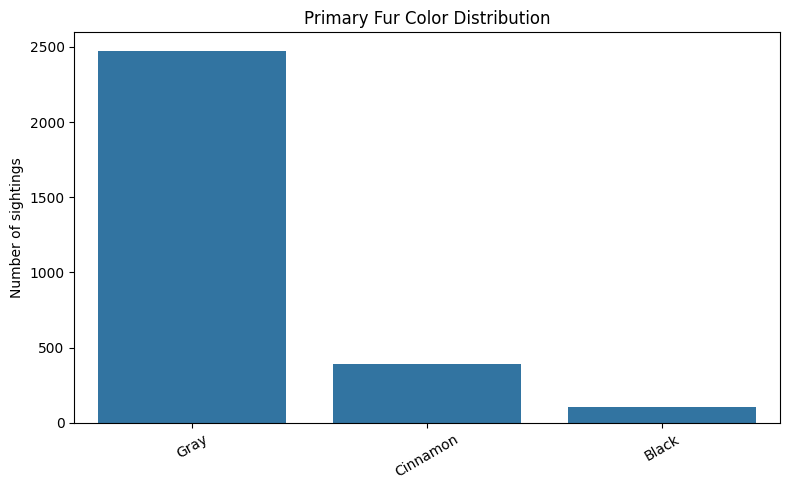

In [6]:
# Cell 6: bar chart of fur color
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Primary Fur Color', order=df['Primary Fur Color'].value_counts().index)
plt.title('Primary Fur Color Distribution')
plt.xlabel('')
plt.ylabel('Number of sightings')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('outputs/fur_color.png', dpi=300, bbox_inches='tight')
plt.show()

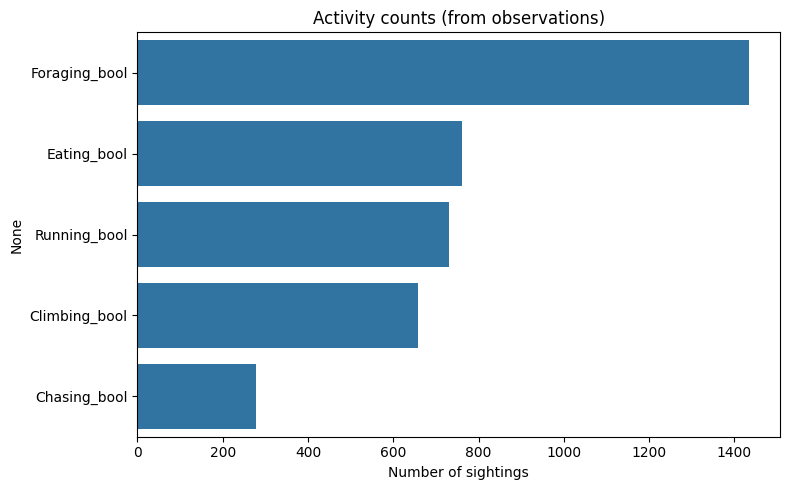

In [7]:
# Cell 7: activity counts
activity_cols = [c + '_bool' for c in ['Running','Chasing','Climbing','Eating','Foraging'] if c + '_bool' in df.columns]
activity_counts = df[activity_cols].sum().sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=activity_counts.values, y=activity_counts.index)
plt.title('Activity counts (from observations)')
plt.xlabel('Number of sightings')
plt.tight_layout()
plt.savefig('outputs/activity_counts.png', dpi=300, bbox_inches='tight')
plt.show()

Approach rate by primary fur color (percent):
 Primary Fur Color
Cinnamon    11.22
Black        5.83
Gray         5.10
dtype: float64


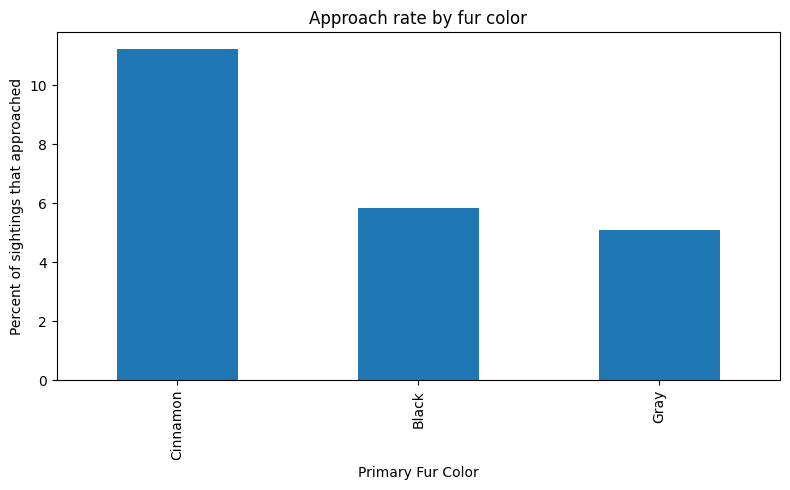

In [8]:
# Cell 8: approach by color
if 'Approaches_bool' in df.columns and 'Primary Fur Color' in df.columns:
    approaches_by_color = df[df['Approaches_bool']].groupby('Primary Fur Color').size()
    total_by_color = df.groupby('Primary Fur Color').size()
    rate_by_color = (approaches_by_color / total_by_color).fillna(0).sort_values(ascending=False)
    rate_by_color = rate_by_color * 100  # percent
    print("Approach rate by primary fur color (percent):\n", rate_by_color.round(2))

    plt.figure(figsize=(8,5))
    rate_by_color.plot(kind='bar')
    plt.ylabel('Percent of sightings that approached')
    plt.title('Approach rate by fur color')
    plt.tight_layout()
    plt.savefig('outputs/approach_by_color.png', dpi=300, bbox_inches='tight')
    plt.show()

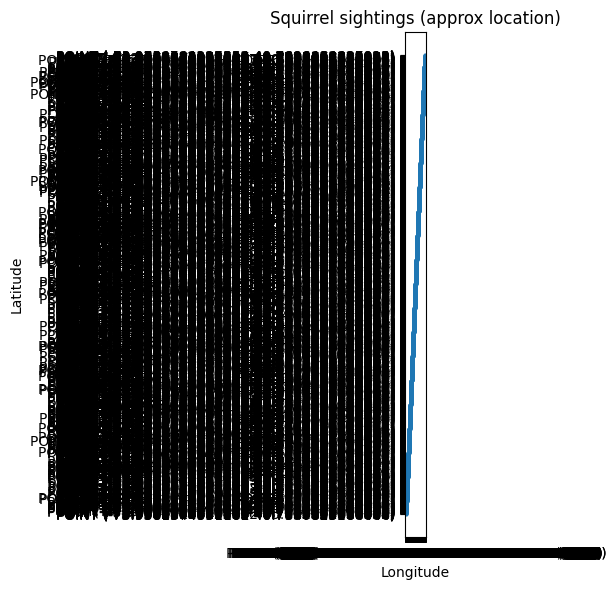

In [9]:
# Cell 9: map scatter (latitude/longitude)
lat_cols = [c for c in df.columns if 'lat' in c.lower()]
lon_cols = [c for c in df.columns if 'long' in c.lower() or 'lon' in c.lower()]

if lat_cols and lon_cols:
    lat_col = lat_cols[0]
    lon_col = lon_cols[0]
    plt.figure(figsize=(6,6))
    plt.scatter(df[lon_col], df[lat_col], s=4, alpha=0.6)
    plt.title('Squirrel sightings (approx location)')
    plt.xlabel('Longitude'); plt.ylabel('Latitude')
    plt.tight_layout()
    plt.savefig('outputs/sightings_map.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("No lat/long columns detected. (OK to skip)")

In [10]:
# Cell 10: final printed summary 
approach_percent = (df['Approaches_bool'].mean() * 100) if 'Approaches_bool' in df.columns else None
print("=== SUMMARY ===")
print(f"Total sightings: {len(df)}")
if approach_percent is not None:
    print(f"Approx approach rate: {approach_percent:.2f}%")
if 'Primary Fur Color' in df.columns:
    top_colors = df['Primary Fur Color'].value_counts().head(3)
    print("Top 3 fur colors:\n", top_colors.to_string())

=== SUMMARY ===
Total sightings: 3023
Approx approach rate: 5.89%
Top 3 fur colors:
 Primary Fur Color
Gray        2473
Cinnamon     392
Black        103
